# RNN Model

In [1]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

### DATA CARD
| Index | Features | Format | Description |
|---|---|---|---|
| 1 | Date Time | 01.01.2009 00:10:00 | Date-time reference |
| 2 | p (mbar) | 996.52 | The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars. |
| 3 | T (degC) | -8.02 | Temperature in Celsius |
| 4 | Tpot (K) | 265.4 | Temperature in Kelvin |
| 5 | Tdew (degC) | -8.9 | Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses. |
| 6 | rh (%) | 93.3 | Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects. |
| 7 | VPmax (mbar) | 3.33 | Saturation vapor pressure |
| 8 | VPact (mbar) | 3.11 | Vapor pressure |
| 9 | VPdef (mbar) | 0.22 | Vapor pressure deficit |
| 10 | sh (g/kg) | 1.94 | Specific humidity |
| 11 | H2OC (mmol/mol) | 3.12 | Water vapor concentration |
| 12 | rho (g/m ** 3) | 1307.75 | Airtight |
| 13 | wv (m/s) | 1.03 | Wind speed |
| 14 | max. wv (m/s) | 1.75 | Maximum wind speed |
| 15 | wd (deg) | 152.3 | Wind direction in degrees |

Setting constants

In [3]:
# Set random seeds for reproducibility
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def rmsle(y_true, y_pred):
    # Adding a small constant to avoid log(0)
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

# 2. OUR ENGINEERING WRAPPER
# We shift Celsius to Kelvin so the professor's log1p function doesn't crash on negative winter temperatures.
TEMP_OFFSET = 273.15 

def rmsle_shifted(y_true, y_pred):
    # Shift values to Kelvin
    y_true_k = tf.cast(y_true, tf.float32) + TEMP_OFFSET
    y_pred_k = tf.cast(y_pred, tf.float32) + TEMP_OFFSET
    
    # Pass the safe, positive values into the professor's exact metric
    return rmsle(y_true_k, y_pred_k)

In [4]:
# check TensorFlow version and GPU availability
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    # Restrict TensorFlow to only use the first GPU
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("Logical GPUs available:", tf.config.list_logical_devices('GPU'))
    print('CUDA GPU available:', is_cuda_gpu_available := tf.test.is_gpu_available(cuda_only=True))

TensorFlow: 2.10.0
Logical GPUs available: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
CUDA GPU available: True


Loading dataset

In [5]:
csv_path = 'jena_climate_2009_2016.csv' 
df = pd.read_csv(csv_path)

# check import is OK
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
# Index the DataFrame by the date column, convert it to datetime, and sort by date
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time').sort_index()

df.head(5)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [7]:
temp_col = [c for c in df.columns if 'T (' in c or 'temp' in c.lower() or 'T (degC)' in c]

TEMP_COL = temp_col[0]

print(f'Temperature column: "{TEMP_COL}"')
print('Date range:', df.index[0], '→', df.index[-1])
print('Total rows:', len(df))
print('Frequency:', pd.infer_freq(df.index[:100]))

Temperature column: "T (degC)"
Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Total rows: 420551
Frequency: 10min


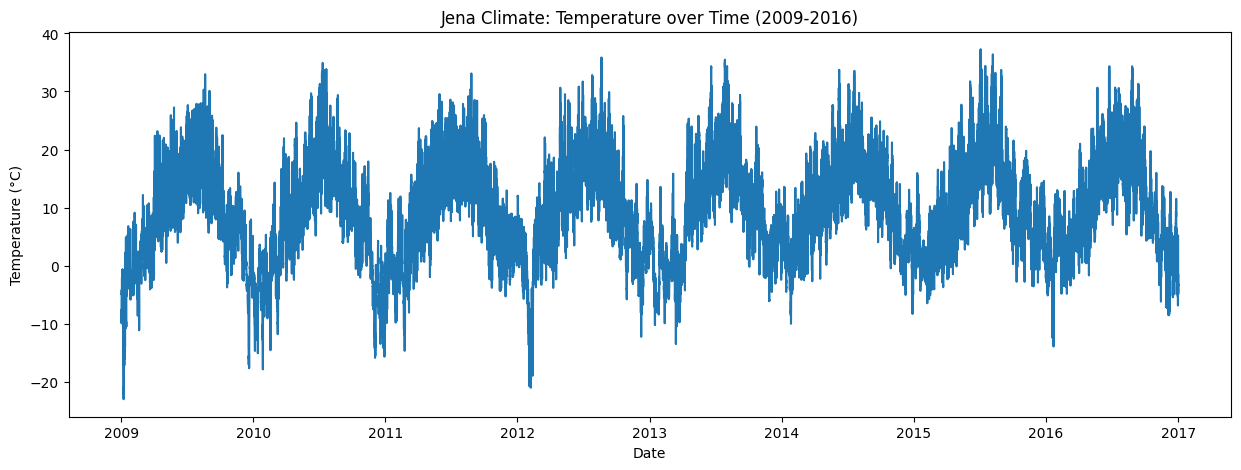

In [8]:
# Plot Temperature over time to visualize seasonality
plt.figure(figsize=(15, 5))
plt.plot(df['T (degC)'])
plt.title('Jena Climate: Temperature over Time (2009-2016)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

In [9]:
# Display summary statistics and check for missing values
display(df.describe())
print('\nMissing values per column:')
display(df.isna().sum())

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000



Missing values per column:


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [10]:
# Downsample to hourly data (every 6th record)
df_hourly = df.iloc[5::6].copy()

# Define split indices
n = len(df_hourly)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_hourly.iloc[:train_end]
val_df = df_hourly.iloc[train_end:val_end]
test_df = df_hourly.iloc[val_end:]

# 1. Scale Features (X) using StandardScaler
scaler_X = StandardScaler()
train_scaled_X = scaler_X.fit_transform(train_df)
val_scaled_X = scaler_X.transform(val_df)
test_scaled_X = scaler_X.transform(test_df)

# 2. NEW CONCEPT: Use RAW target values directly from the dataframe
train_targets_y = train_df['T (degC)'].values
val_targets_y = val_df['T (degC)'].values
test_targets_y = test_df['T (degC)'].values

def create_dataset(data_x, data_y, window_size, delay=24, batch_size=256):
    """Creates aligned X and y datasets with correct offset."""
    offset = window_size + delay - 1 
    
    inputs = data_x[:-offset]
    targets = data_y[offset:]
    
    return tf.keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=window_size,
        batch_size=batch_size,
        shuffle=False
    )

In [ ]:
# Define configurations for experiments
time_windows = [24, 72, 168] # 1 day, 3 days, 7 days
architectures = ['SimpleRNN', 'GRU', 'LSTM', ]

# FIXED: Updated to train_scaled_X to match our corrected preprocessing step
features = train_scaled_X.shape[1] 

# Dictionary to store results
results_dict = {}

In [12]:
def build_model(arch_type, window_size, num_features):
    model = Sequential()
    model.add(Input(shape=(window_size, num_features)))
    
    if arch_type == 'SimpleRNN':
        model.add(SimpleRNN(32, activation='tanh', unroll=True))
    elif arch_type == 'LSTM':
        model.add(LSTM(32, activation='tanh', unroll=True))
    elif arch_type == 'GRU':
        # NEW: Add the GRU layer
        model.add(GRU(32, activation='tanh', unroll=True))
        
    model.add(Dense(1)) # Pure regression output
    
    optimizer = Adam(clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=[rmsle_shifted])
    return model

In [13]:
EPOCHS = 20
BATCH_SIZE = 256

for window in time_windows:
    # Pass both the scaled Features (X) and the unscaled Kelvin Targets (y)
    train_ds = create_dataset(train_scaled_X, train_targets_y, window_size=window, batch_size=BATCH_SIZE)
    val_ds = create_dataset(val_scaled_X, val_targets_y, window_size=window, batch_size=BATCH_SIZE)
    test_ds = create_dataset(test_scaled_X, test_targets_y, window_size=window, batch_size=BATCH_SIZE)
    
    for arch in architectures:
        print(f"\n--- Training {arch} with {window}h window ---")
        model = build_model(arch, window, num_features=train_scaled_X.shape[1])        
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=3, 
            restore_best_weights=True
        )
        
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=[early_stopping],
            verbose=1
        )
        
        test_loss, test_rmsle = model.evaluate(test_ds, verbose=0)
        print(f"Test RMSLE: {test_rmsle:.4f}")
        
        # Save results
        key = f"{arch}_{window}h"
        results_dict[key] = {
            'history': history.history,
            'test_rmsle': test_rmsle,
            'model': model,
            'test_ds': test_ds
        }


--- Training SimpleRNN with 24h window ---
Epoch 1/20
192/192 [==============================] - 4s 14ms/step - loss: 107.5498 - rmsle_shifted: 0.0329 - val_loss: 59.0463 - val_rmsle_shifted: 0.0241
Epoch 2/20
192/192 [==============================] - 2s 10ms/step - loss: 61.4177 - rmsle_shifted: 0.0263 - val_loss: 61.5830 - val_rmsle_shifted: 0.0264
Epoch 3/20
192/192 [==============================] - 2s 10ms/step - loss: 54.1105 - rmsle_shifted: 0.0247 - val_loss: 47.6418 - val_rmsle_shifted: 0.0226
Epoch 4/20
192/192 [==============================] - 2s 10ms/step - loss: 43.2773 - rmsle_shifted: 0.0219 - val_loss: 35.8141 - val_rmsle_shifted: 0.0193
Epoch 5/20
192/192 [==============================] - 2s 10ms/step - loss: 35.1761 - rmsle_shifted: 0.0197 - val_loss: 27.7851 - val_rmsle_shifted: 0.0167
Epoch 6/20
192/192 [==============================] - 2s 10ms/step - loss: 28.5469 - rmsle_shifted: 0.0176 - val_loss: 23.3086 - val_rmsle_shifted: 0.0153
Epoch 7/20
192/192 [=====

In [14]:
# 1. Compare RMSLE Results
print("\n--- Final RMSLE Comparison ---")
for key, data in results_dict.items():
    print(f"{key}: {data['test_rmsle']:.4f}")

# 2. Identify Best and Worst Cases
best_model_key = min(results_dict, key=lambda k: results_dict[k]['test_rmsle'])
best_model = results_dict[best_model_key]['model']
best_test_ds = results_dict[best_model_key]['test_ds']

print(f"\nExtracting cases using best model: {best_model_key}")

all_y_true = []
all_y_pred = []

# Iterate through test dataset to get predictions
for x_batch, y_batch in best_test_ds:
    preds = best_model.predict(x_batch, verbose=0)
    
    all_y_true.extend(y_batch.numpy().flatten())
    all_y_pred.extend(preds.flatten())

# Convert to numpy arrays (Already in real degrees Celsius!)
true_celsius = np.array(all_y_true)
pred_celsius = np.array(all_y_pred)

# Calculate absolute errors
errors_celsius = np.abs(true_celsius - pred_celsius)
error_indices = np.argsort(errors_celsius)

# Best cases (smallest error)
best_cases_idx = error_indices[:3]
# Worst cases (largest error)
worst_cases_idx = error_indices[-3:]

print("\n--- Top 3 Best Case Scenarios (in °C) ---")
for i, idx in enumerate(best_cases_idx):
    print(f"{i+1}. True Temp: {true_celsius[idx]:.2f}°C | Predicted: {pred_celsius[idx]:.2f}°C | Error: {errors_celsius[idx]:.2f}°C")

print("\n--- Top 3 Worst Case Scenarios (in °C) ---")
for i, idx in enumerate(worst_cases_idx):
    print(f"{i+1}. True Temp: {true_celsius[idx]:.2f}°C | Predicted: {pred_celsius[idx]:.2f}°C | Error: {errors_celsius[idx]:.2f}°C")


--- Final RMSLE Comparison ---
SimpleRNN_24h: 0.0114
LSTM_24h: 0.0113
GRU_24h: 0.0109
SimpleRNN_72h: 0.0113
LSTM_72h: 0.0106
GRU_72h: 0.0105
SimpleRNN_168h: 0.0116
LSTM_168h: 0.0116
GRU_168h: 0.0107

Extracting cases using best model: GRU_72h

--- Top 3 Best Case Scenarios (in °C) ---
1. True Temp: 0.85°C | Predicted: 0.85°C | Error: 0.00°C
2. True Temp: 20.16°C | Predicted: 20.16°C | Error: 0.00°C
3. True Temp: 14.86°C | Predicted: 14.86°C | Error: 0.00°C

--- Top 3 Worst Case Scenarios (in °C) ---
1. True Temp: 34.16°C | Predicted: 20.42°C | Error: 13.74°C
2. True Temp: 34.29°C | Predicted: 20.42°C | Error: 13.87°C
3. True Temp: 34.34°C | Predicted: 20.42°C | Error: 13.92°C


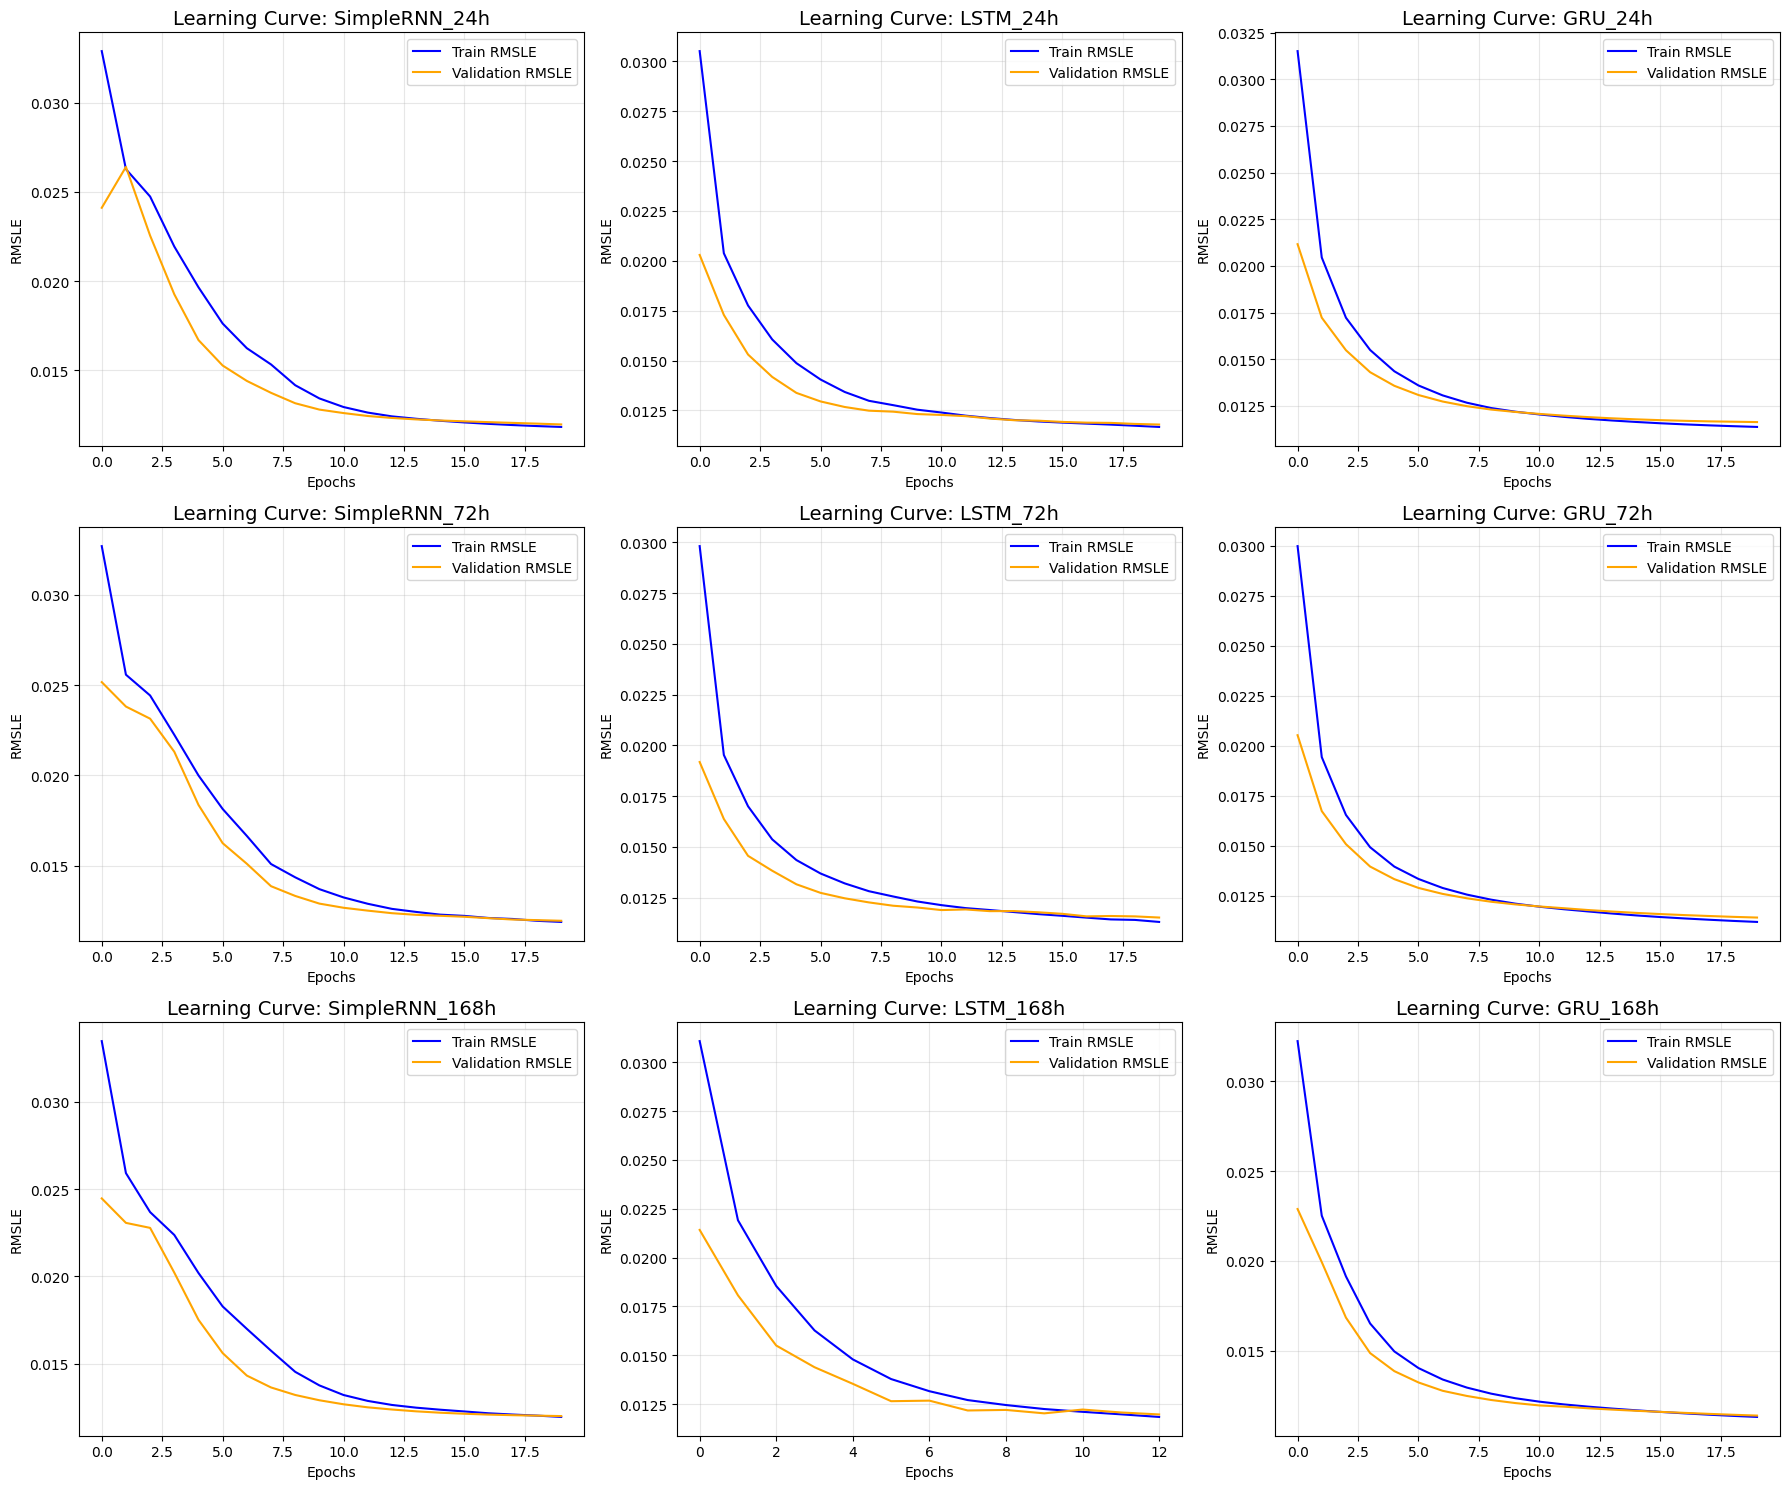

In [15]:
import matplotlib.pyplot as plt
import math

# Calculate grid size based on the number of experiments
num_experiments = len(results_dict)
cols = len(architectures) # e.g., 3 (SimpleRNN, LSTM, GRU)
rows = math.ceil(num_experiments / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, (key, data) in enumerate(results_dict.items()):
    history = data['history']
    
    # Keras dynamically names the metric based on the function name
    train_metric = [k for k in history.keys() if 'rmsle' in k and 'val' not in k][0]
    val_metric = [k for k in history.keys() if 'val_rmsle' in k][0]
    
    axes[i].plot(history[train_metric], label='Train RMSLE', color='blue')
    axes[i].plot(history[val_metric], label='Validation RMSLE', color='orange')
    axes[i].set_title(f'Learning Curve: {key}', fontsize=14)
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('RMSLE')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots if the grid isn't perfectly full
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

--- Best Model (GRU_72h) successfully saved to: saved_models\best_rnn_model_GRU_72h.keras ---


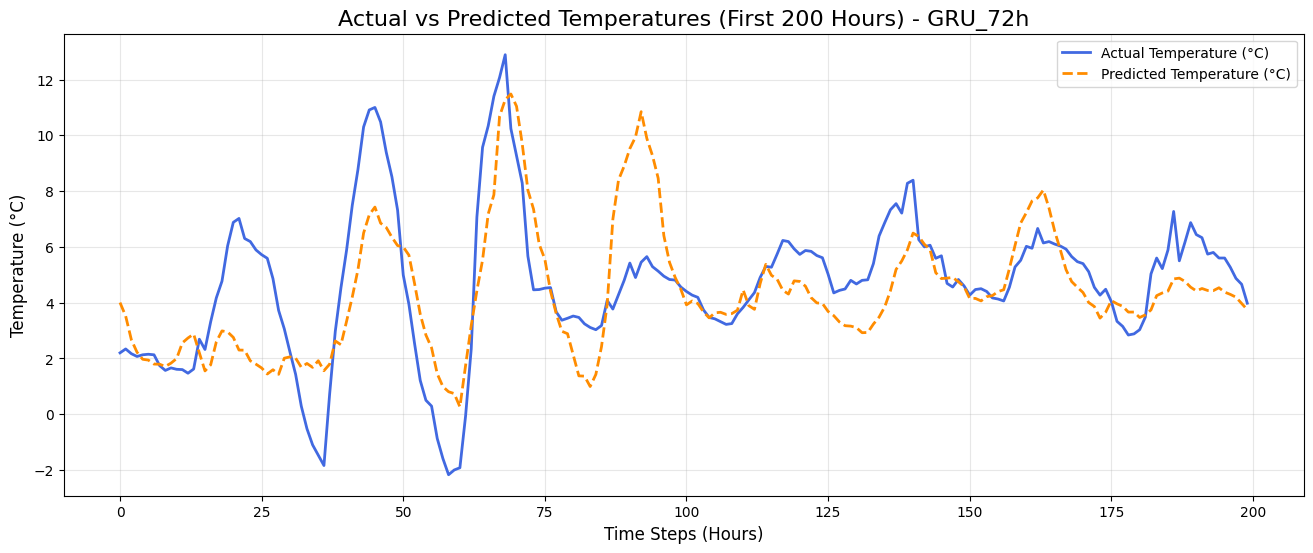

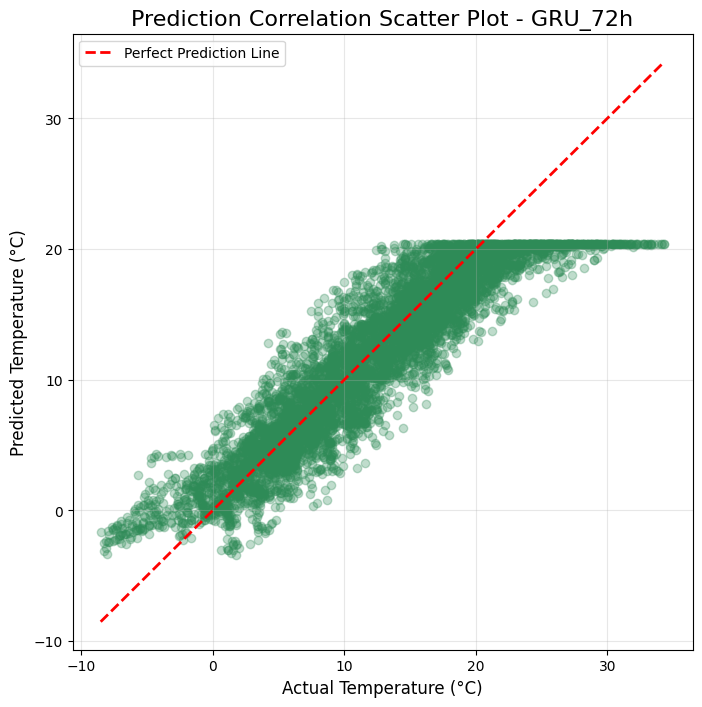

In [16]:
# 1. Save the Best Model
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, f'best_rnn_model_{best_model_key}.keras')

best_model.save(best_model_path)
print(f"--- Best Model ({best_model_key}) successfully saved to: {best_model_path} ---")


# 2. Line Plot: Actual vs Predicted (Zoomed in on 200 hours)
plt.figure(figsize=(16, 6))
# We plot just the first 200 steps to make the daily cycles visible
plt.plot(true_celsius[:200], label='Actual Temperature (°C)', color='royalblue', linewidth=2)
plt.plot(pred_celsius[:200], label='Predicted Temperature (°C)', color='darkorange', linewidth=2, linestyle='--')
plt.title(f'Actual vs Predicted Temperatures (First 200 Hours) - {best_model_key}', fontsize=16)
plt.xlabel('Time Steps (Hours)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


# 3. Scatter Plot: Overall Prediction Accuracy
plt.figure(figsize=(8, 8))
plt.scatter(true_celsius, pred_celsius, alpha=0.3, color='seagreen')

# Draw the "Perfect Prediction" diagonal line
min_val = min(min(true_celsius), min(pred_celsius))
max_val = max(max(true_celsius), max(pred_celsius))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title(f'Prediction Correlation Scatter Plot - {best_model_key}', fontsize=16)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print("Best model summary:")

best_model.summary()